# Resumen documento
A lo largo de este documento se muestran ejemplos del uso de la biblioteca de Bloquade: representar las Rabi oscillation (one and two qubits cases), simulación de Many-body dinamics (lo de las transiciones de fase)

Recreado del tutorial de QuEra: https://github.com/QuEraComputing/quera-education/tree/main/Bloqade_Python_Tutorial/1_Basics 


In [1]:
from bloqade.analog import start, cast, load, save
import os
import matplotlib.pyplot as plt
from bokeh.io import output_notebook
from bloqade.analog.atom_arrangement import ListOfLocations, Square
from bloqade.analog import  piecewise_linear, cast
import numpy as np
output_notebook()

if not os.path.isdir("data"):
    os.mkdir("data")

c:\Users\javip\Documents\Códigos_TFG\Codigo_tfg\.venv\Lib\site-packages\bloqade\analog\__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


Loading BokehJS ...

# 1. Rabi oscillation: Single atom case
Simulamos al estado de un solo átomo al aplicarle una Rabi frequency. Para ver la evolución del estado se realizan simulaciones con diferentes tiempos finales y se grafican al final.

In [2]:
atom_coordinate=ListOfLocations([(0,0)])
atom_coordinate.show()

ramp_time=0.06
rabi_ampl=15
detuning_value=0.0
run_time=1.0

durations = [ramp_time, run_time, ramp_time]
values=[0, rabi_ampl, rabi_ampl, 0]
waveform_rabi = piecewise_linear(durations, values)
waveform_rabi.show()

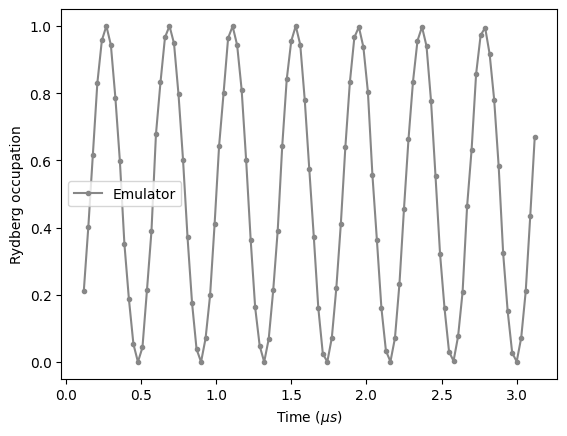

In [3]:
register1 = ( start.add_position((0, 0)))
durations = cast(["ramp_time", "run_time", "ramp_time"])


register_rabi = (
    register1
    .rydberg.rabi.amplitude.uniform.piecewise_linear(durations=durations, values=[0, "rabi_ampl", "rabi_ampl", 0])
)


rabi_oscillations_program = (
    register_rabi
    .detuning.uniform.constant(duration=sum(durations), value="detuning_value")
)


durations = cast(["ramp_time", "run_time", "ramp_time"])

rabi_oscillations_program = (
    start.add_position((0, 0))
    .rydberg.rabi.amplitude.uniform.piecewise_linear(durations=durations, values=[0, "rabi_ampl", "rabi_ampl", 0])
    .detuning.uniform.constant(duration=sum(durations), value="detuning_value")
)


run_times = np.linspace(0, 3, 101)

ramp_time=0.06
rabi_ampl=15
detuning_value=0.0

rabi_oscillation_job = rabi_oscillations_program.assign(
    ramp_time=ramp_time, rabi_ampl=rabi_ampl, detuning_value=detuning_value
).batch_assign(run_time=run_times)



emu_filename = os.path.join(os.path.abspath(""), "data", "rabi-emulation.json")

if not os.path.isfile(emu_filename):
    emu_batch = rabi_oscillation_job.braket.local_emulator().run(1000)
    save(emu_batch, emu_filename)



emu_batch = load(emu_filename)

#hardware_report = hardware_batch.report()
emulator_report = emu_batch.report()

times = emulator_report.list_param("run_time")
for i in range (len(times)):
    times[i]=times[i]+ 2*ramp_time
density = [1 - ele.mean() for ele in emulator_report.bitstrings()]
plt.plot(times, density, color="#878787", marker=".", label="Emulator")

plt.xlabel("Time ($\mu s$)")
plt.ylabel("Rydberg occupation")
plt.legend()
plt.show()

# 2. Two qubits dynamics
Graficamos la evolución de cuántos Rydberg states hay a lo largo del tiempo para dos átomos.

Resultados: Para distancias pequeñas (ej. dist menores a 8), la gráfica es prácticamente sinusoidal con máxima densidad 1 (también tarda más en ejecutar). Aunque el $R_B$ sea 8.7, aún con dist=8 los máximos de las densidades llegan a 1,25 (mayor que 1). 

Al ir aumentando la distancia el máximo de la primera oscilación va aumentando progesivamente, pero es curioso que las siguientes oscilaciones a veces no alcanzan máximos y mínimos tan extremos. 

Para dist = 13 las oscilaciones ya oscilan todas entre 2 y 0 (el ryberg blockade prácticamente no influye)

Rydberg Radius:  8.692355131311515


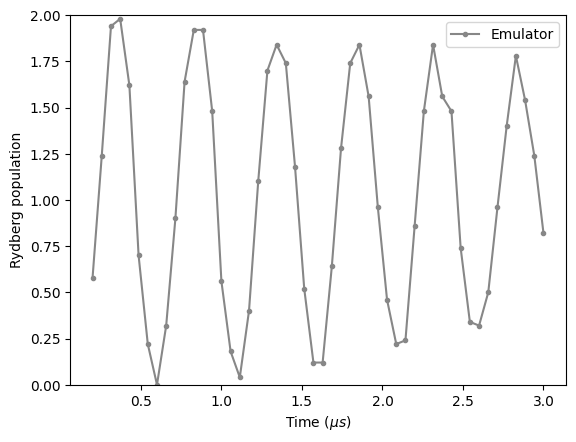

In [4]:
detuning=0
max_omega = 2*np.pi*2
C6 = 2*np.pi * 862690
Rb = (C6 / max_omega) ** (1/6)
print("Rydberg Radius: ",Rb)


#pick a distance!
dist = 13
atom_coord=[(0, 0), (0,dist)]
#ListOfLocations(atom_coord).show()



def many_body_dynamics(atom_coord, max_omega, max_run_time):

    run_times = np.linspace(0, max_run_time-0.2, 50)
    n_atom = len(atom_coord)
    
    program = (
        start.add_position(atom_coord)
        .rydberg.rabi.amplitude.uniform.piecewise_linear(durations = [0.1, "run_time", 0.1],values = [0, max_omega, max_omega, 0])
        .detuning.uniform.constant(duration=sum(run_times), value=0)
        )
    
    two_atom_job = program.batch_assign(run_time=run_times)
    
    emulator_batch = two_atom_job.bloqade.python().run(50)
    
    emulator_report=emulator_batch.report()
    times = emulator_report.list_param("run_time")
    for i in range (len(times)):
        times[i]=times[i]+ 0.2
    density = [n_atom - n_atom*ele.mean() for ele in emulator_report.bitstrings()]
    plt.plot(times, density, color="#878787", marker=".", label="Emulator")
    
    plt.ylim(0, n_atom) 
    plt.xlabel("Time ($\mu s$)")
    plt.ylabel("Rydberg population")
    plt.legend()
    plt.show()


max_run_time = 3

many_body_dynamics(atom_coord, max_omega,max_run_time)

# 3. Many body dynamics
![descripción](https://raw.githubusercontent.com/QuEraComputing/quera-education/bdafe58e4629136135254689dbe14c1bbb537397/Bloqade_Python_Tutorial/2_Rabi_and_ordered_phases/assets/square_phasediagram.png)

In [5]:
from bloqade.analog import start, cast, load, save
import os
import matplotlib.pyplot as plt
from bokeh.io import output_notebook
from bloqade.analog.atom_arrangement import ListOfLocations, Square
from bloqade.analog import  piecewise_linear, cast
import numpy as np
output_notebook()

if not os.path.isdir("data"):
    os.mkdir("data")
    
# Change the lattice spacing to vary the atom separation a, and thus also Rb/a
delta_end=8 #final detuning
omega_max=3.3 #max Rabi amplitude
sweep_time = 2.4 #time length of program 
lattice_spacing = 7 #size of edges of square lattice
L=4 # number of unit cells in each direction

C6 = 2*np.pi * 862690
Rb = (C6 / (omega_max) )** (1/6) # R_B during bulk of protocol
print("Rb/a: ",Rb/lattice_spacing)
print("Delta/Omega: ", delta_end/omega_max)


# Establecemos los parámetros y definimos el programa
rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
rabi_detuning_values = [-delta_end, -delta_end, delta_end, delta_end]
durations = [0.8, sweep_time, 0.8]

geometria=Square(L, lattice_spacing=lattice_spacing)
#geometria.show()
prog = (
    geometria
    .rydberg.rabi.amplitude.uniform.piecewise_linear(durations, rabi_amplitude_values)
    .detuning.uniform.piecewise_linear(durations, rabi_detuning_values)
)

# Simulamos el programa con el emulador de Bloqade
emu_prog=prog.bloqade.python().run(shots=1)
emu_prog.report().show()

Loading BokehJS ...

Rb/a:  1.5517511480931172
Delta/Omega:  2.4242424242424243
0.0 21000000.0 0.0 21000000.0


In [6]:
# Simulamos el programa con el emulador de Bloqade
emu_prog=prog.bloqade.python().run(shots=1)
emu_prog.report().show()

0.0 21000000.0 0.0 21000000.0
